# Drug classification using Decision Tree models

## Project overview
This project develops and compares multiple Decision Tree classifiers to predict the most appropriate drug based on patient characteristics. Several tree configurations, including Gini, Entropy, pruning, and leaf constraints, are evaluated using classification metrics, confusion matrices, and feature importance analysis.

## Dataset
The dataset contains demographic and clinical information from patients, including age, sex, blood pressure, cholesterol level, sodium-to-potassium ratio (Na_to_K), and the prescribed drug. The objective is to predict the appropriate drug based on these patient characteristics using Decision Tree classification models.

## Import required libraries

In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import os
os.chdir("/Users/hiramtourist/Desktop")

## Load the dataset and inspect its structure

In [4]:
drugs = pd.read_csv('drugs.csv')
drugs.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


## Data understanding

## Check for missing values

In [5]:
drugs.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

## Explore the dataset structure

In [6]:
drugs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


## Explore categorical variables

In [7]:
drugs['Sex'].unique()

array(['F', 'M'], dtype=object)

In [8]:
drugs['BP'].unique()

array(['HIGH', 'LOW', 'NORMAL'], dtype=object)

In [9]:
drugs['Cholesterol'].unique()

array(['HIGH', 'NORMAL'], dtype=object)

## Perform exploratory data analysis (EDA)

In [10]:
drugs[drugs['BP']== 'HIGH'].groupby('Sex').describe().transpose()

Sex                    F          M
Age     count  38.000000  39.000000
        mean   37.842105  46.512821
        std    16.761485  17.696077
        min    15.000000  15.000000
        25%    23.250000  31.000000
        50%    35.500000  48.000000
        75%    54.500000  62.000000
        max    73.000000  74.000000
Na_to_K count  38.000000  39.000000
        mean   19.000711  15.130795
        std     7.394246   7.370150
        min     9.945000   6.269000
        25%    12.864000   9.763000
        50%    18.402500  12.856000
        75%    25.085250  17.750500
        max    37.188000  35.639000

## Visualize the target classes and feature distributions

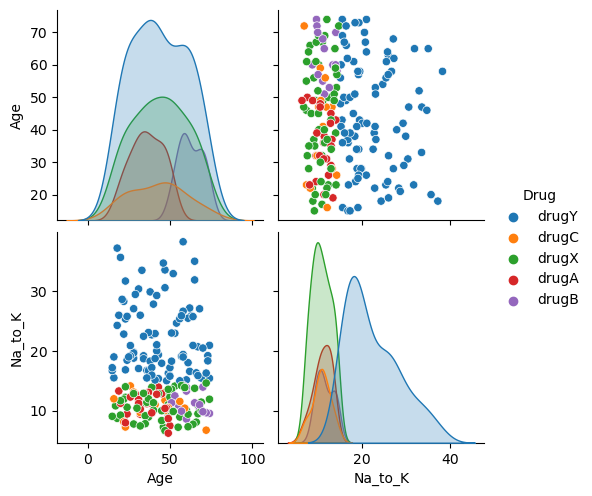

In [12]:
sns.pairplot(drugs,hue = 'Drug')

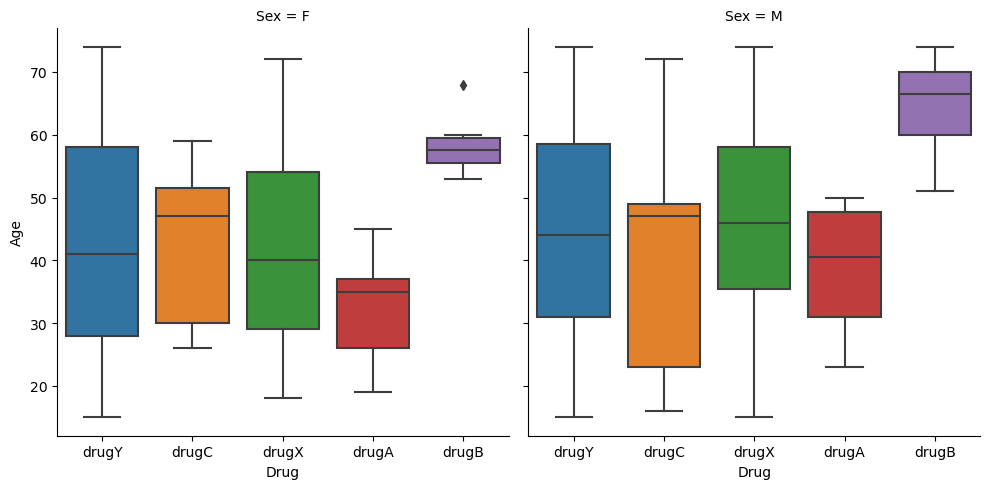

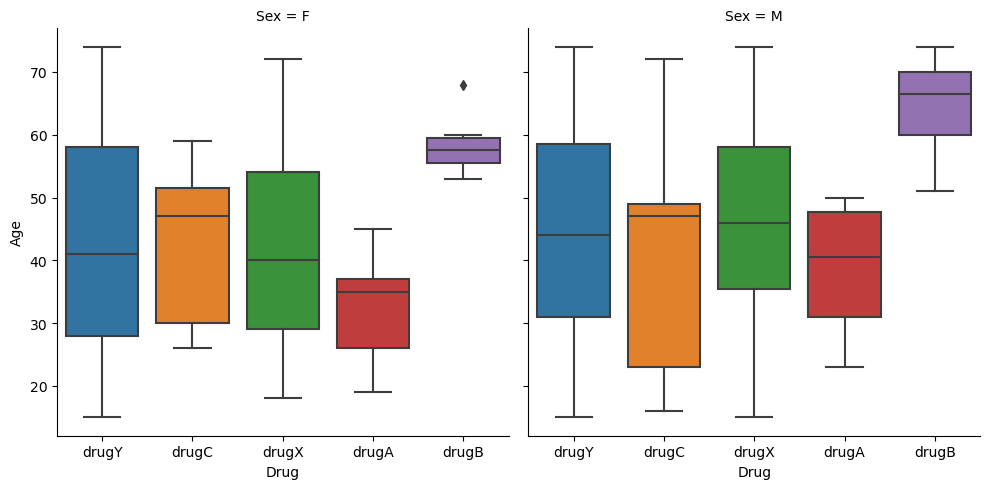

In [14]:
sns.catplot(x = 'Drug', y= 'Age', data = drugs, kind = 'box', col = 'Sex' )
plt.show()

## Baseline Decision Tree: model development

## Encode categorical features and create the feature matrix (X)

In [15]:
X = pd.get_dummies(drugs.drop('Drug',axis = 1), drop_first = True)

## Define the target variable (y)

In [16]:
y = drugs['Drug']

## Split the dataset into training and test sets

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 42)

## Initialize the Decision Tree classifier

In [19]:
model = DecisionTreeClassifier()

## Train a base Decision Tree model

In [20]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

## Display the baseline Decision Tree model rules

In [45]:
from sklearn.tree import export_text
rules = export_text(model, feature_names=X.columns.tolist())
print(rules)

|--- Na_to_K <= 14.83
|   |--- BP_NORMAL <= 0.50
|   |   |--- BP_LOW <= 0.50
|   |   |   |--- Age <= 50.50
|   |   |   |   |--- class: drugA
|   |   |   |--- Age >  50.50
|   |   |   |   |--- class: drugB
|   |   |--- BP_LOW >  0.50
|   |   |   |--- Cholesterol_NORMAL <= 0.50
|   |   |   |   |--- class: drugC
|   |   |   |--- Cholesterol_NORMAL >  0.50
|   |   |   |   |--- class: drugX
|   |--- BP_NORMAL >  0.50
|   |   |--- class: drugX
|--- Na_to_K >  14.83
|   |--- class: drugY



## Generate predictions on the test set

In [21]:
pred_base = model.predict(X_test)

## Model evaluation

## Compute the confusion matrix

In [22]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,pred_base)
cm

array([[ 7,  0,  0,  0,  0],
       [ 0,  3,  0,  0,  0],
       [ 0,  0,  6,  0,  0],
       [ 0,  0,  0, 18,  0],
       [ 0,  0,  0,  0, 26]])

## Import libraries for model Evaluation and confusion matrix visualization

In [23]:
from sklearn.metrics import classification_report, plot_confusion_matrix

## Evaluate the baseline Decision Tree model

In [24]:
print(classification_report(y_test,pred_base))

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         6
       drugX       1.00      1.00      1.00        18
       drugY       1.00      1.00      1.00        26

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



## Visualize the baseline Decision Tree model confusion matrix

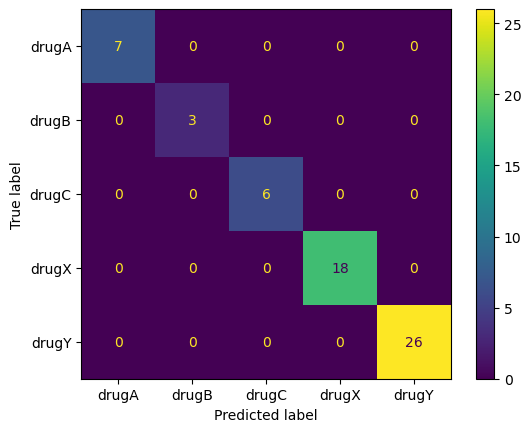

In [42]:
plot_confusion_matrix(model, X_test,y_test)
plt.show()

## Calculate feature importance

In [25]:
model.feature_importances_

array([0.1481685 , 0.47611037, 0.        , 0.12662369, 0.1408883 ,
       0.10820914])

## Visualize feature importance

In [26]:
X.columns

Index(['Age', 'Na_to_K', 'Sex_M', 'BP_LOW', 'BP_NORMAL', 'Cholesterol_NORMAL'], dtype='object')

## Rank features by importance

In [27]:
pd.DataFrame(index = X.columns, data = model.feature_importances_ , columns = ['Feature importance']).sort_values('Feature importance')

,Feature importance
Sex_M,0.000000
Cholesterol_NORMAL,0.108209
BP_LOW,0.126624
BP_NORMAL,0.140888
Age,0.148169
Na_to_K,0.476110


## Visualize the baseline Decision Tree model

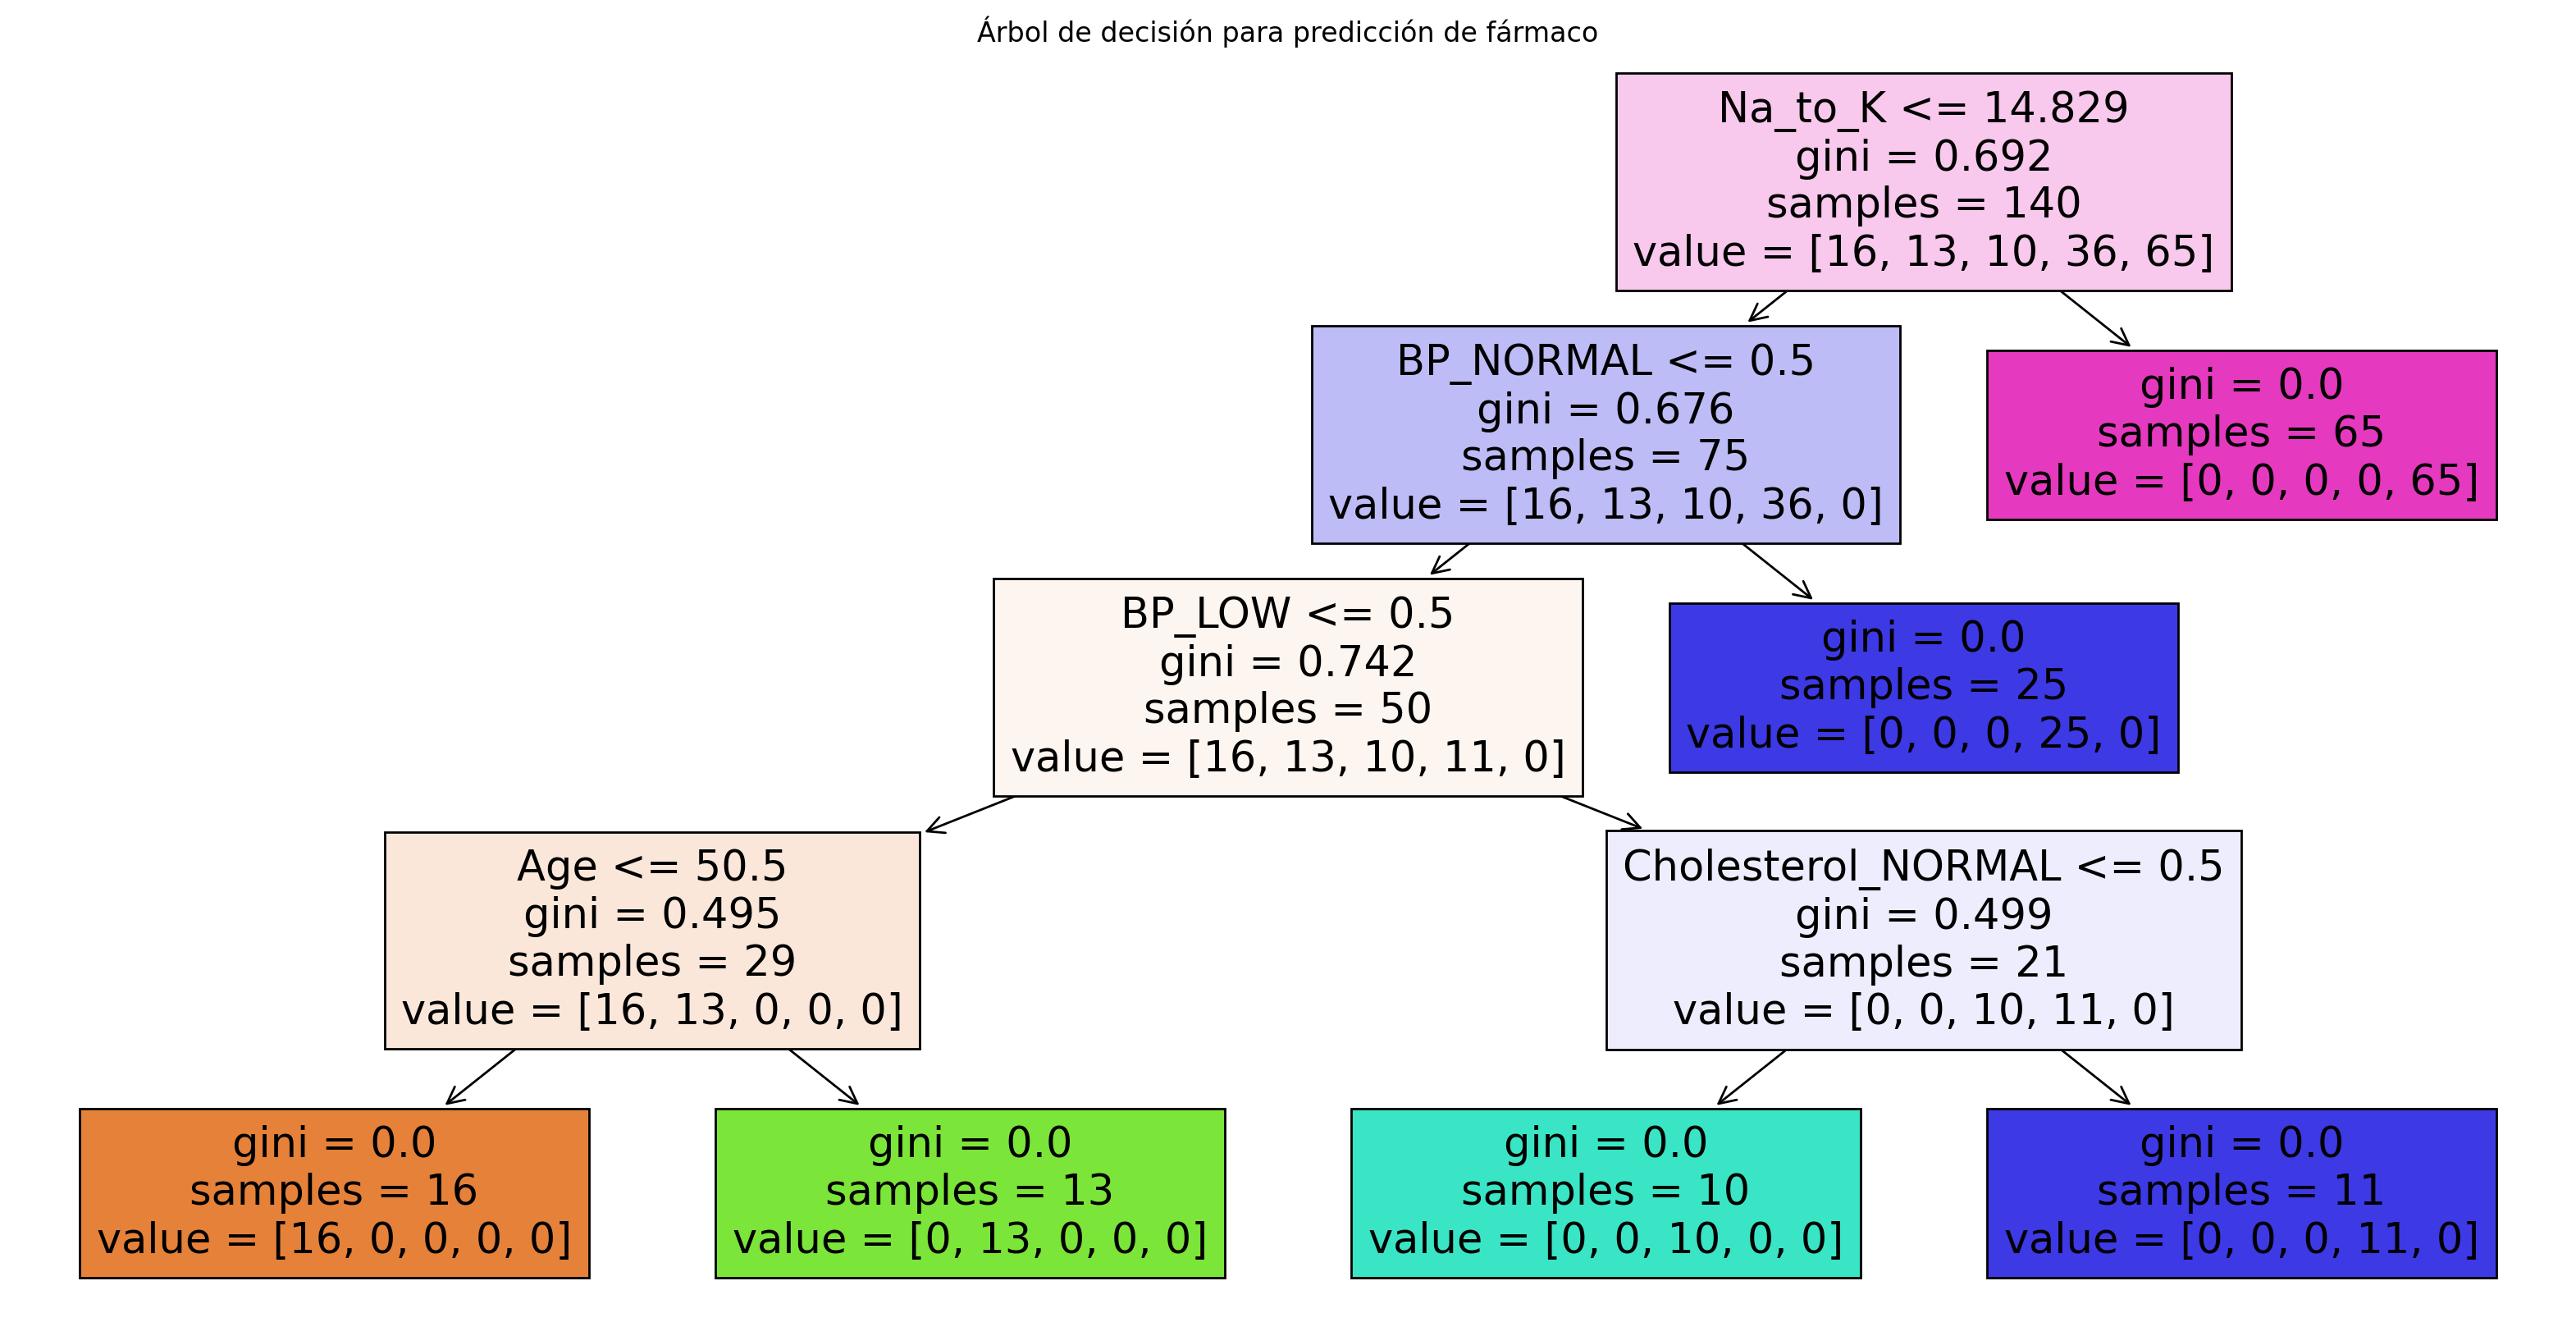

In [28]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10), dpi = 200)
plot_tree(model, feature_names= X.columns, filled=True)
plt.title("Árbol de decisión para predicción de fármaco")
plt.show()

 ## Create a function to display the classification report and visualize the Decision Tree

In [29]:
 def report_model(model):
        model_preds = model.predict(X_test)
        print(classification_report(y_test,model_preds))
        print('\n')
        plt.figure(figsize=(20,10), dpi = 200)
        plot_tree(model, feature_names= X.columns, filled=True)
        plt.show()
 

## Apply the evaluation function to the baseline Decision Tree model

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         6
       drugX       1.00      1.00      1.00        18
       drugY       1.00      1.00      1.00        26

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60





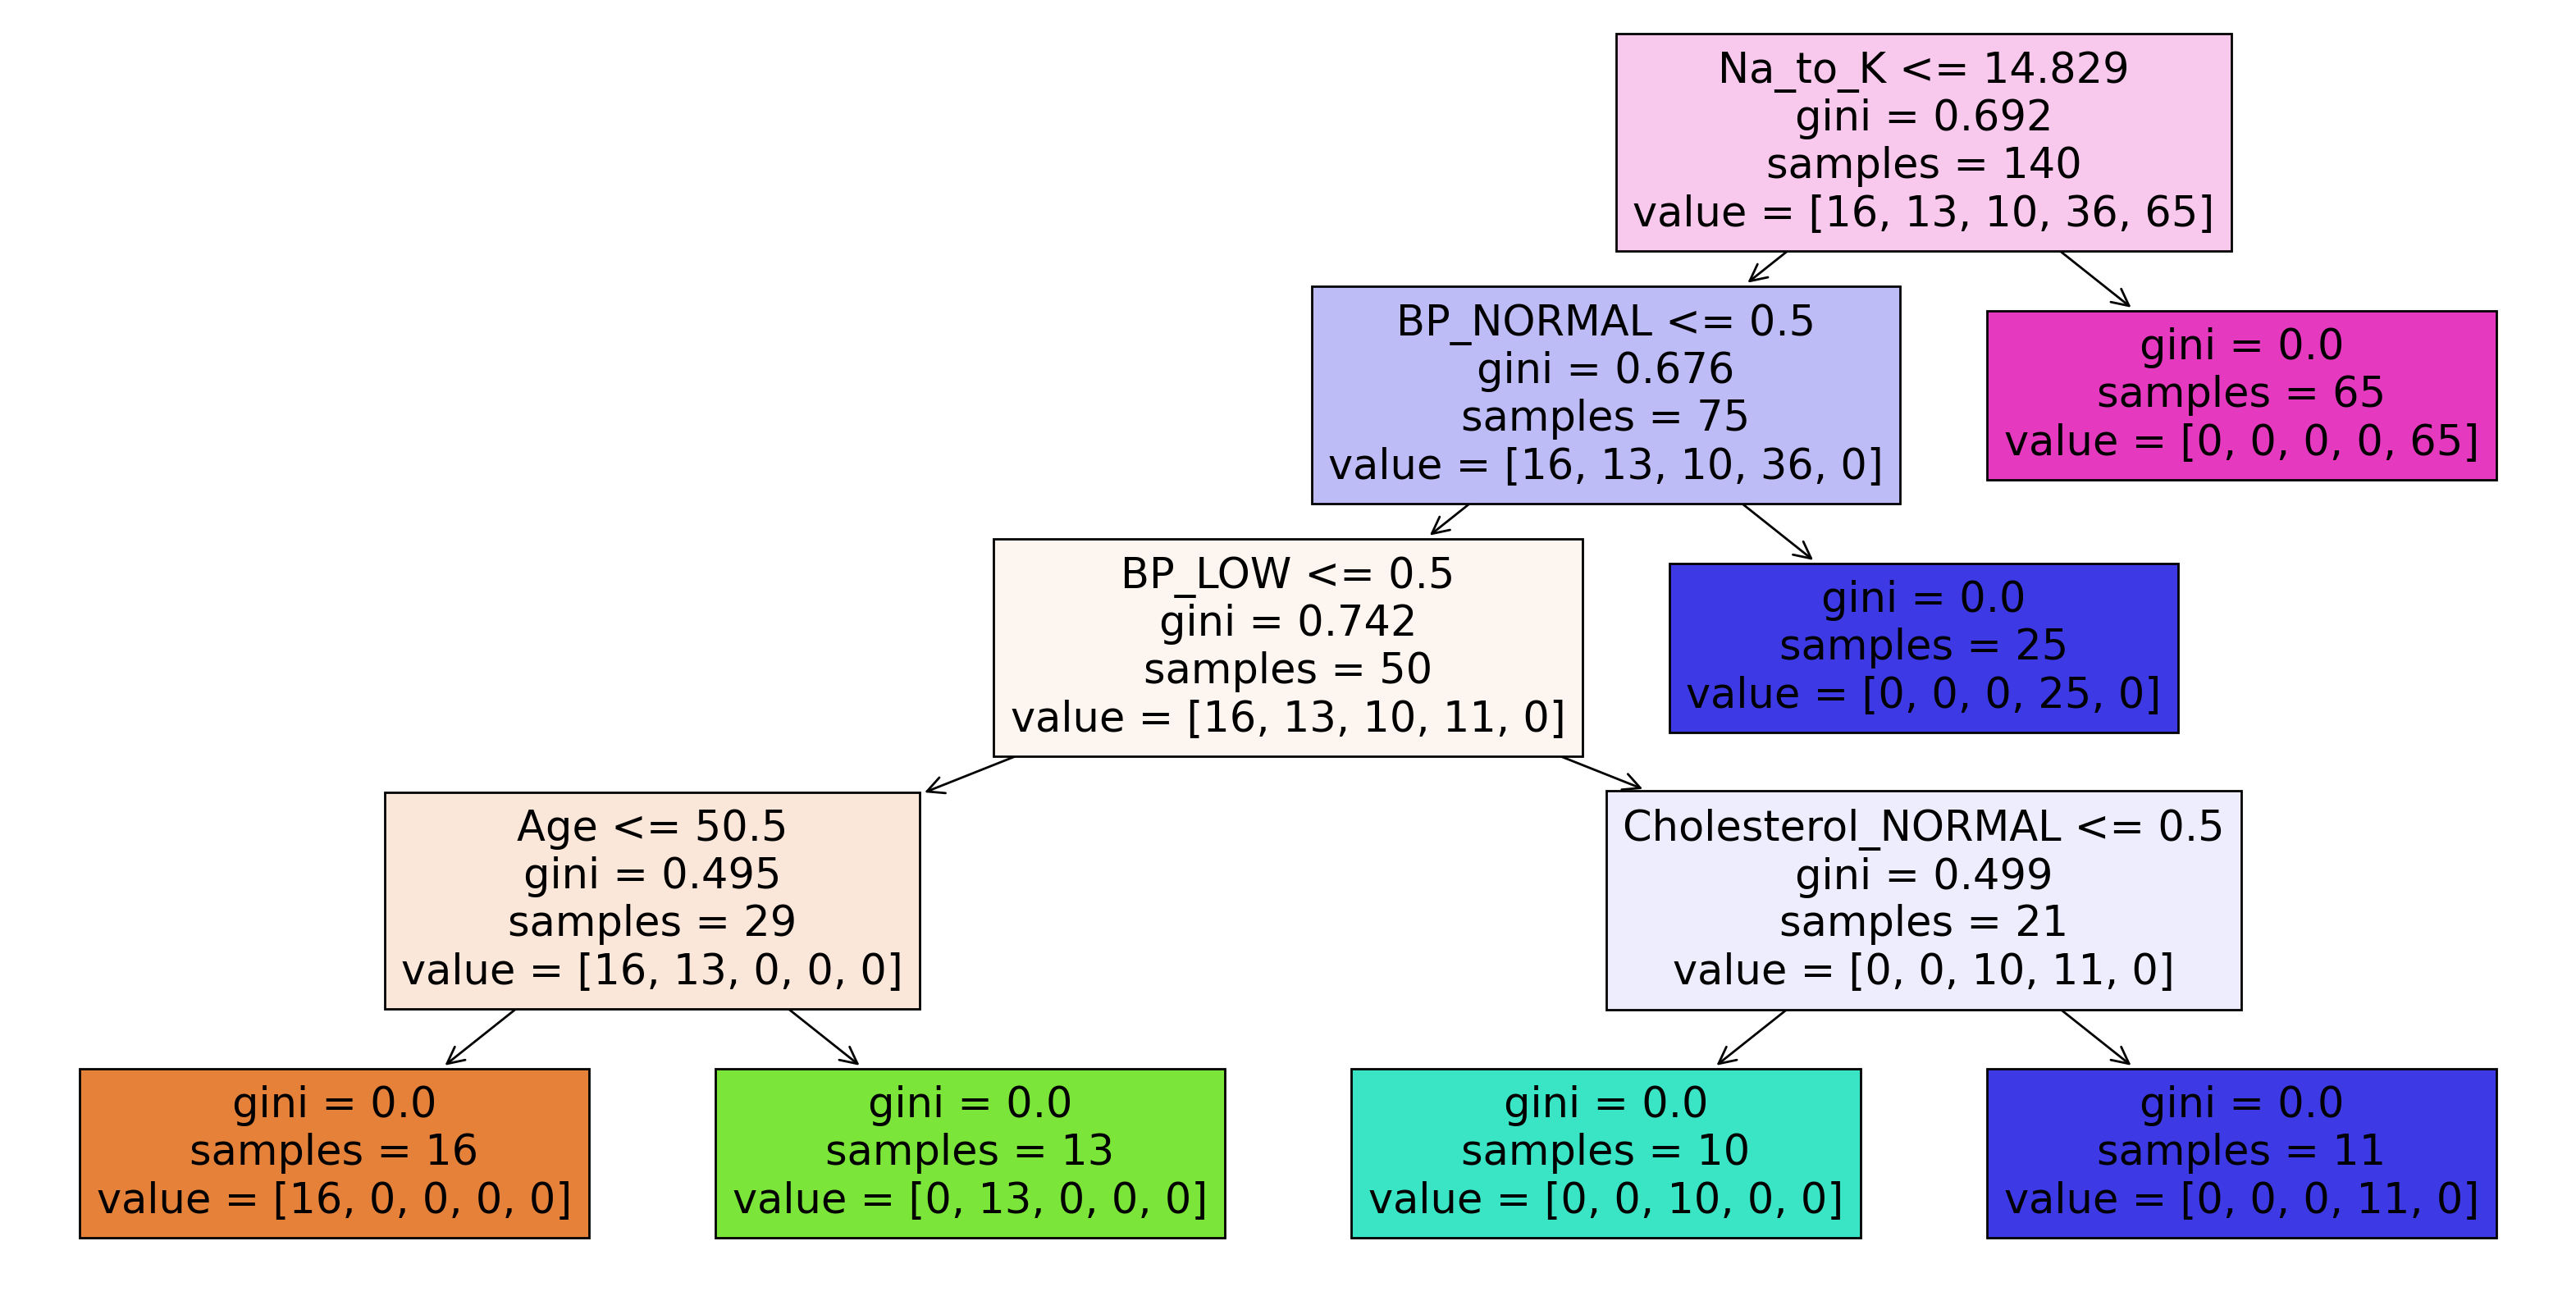

In [30]:
report_model(model)

## Train alternate Decision Trees with modified hyperparameters 

## Pruned Decision Tree (max_depth = 2)

In [33]:
pruned_tree = DecisionTreeClassifier(max_depth = 2)

In [34]:
pruned_tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2)

## Display the pruned Decision Tree rules

In [44]:
from sklearn.tree import export_text
rules_pruned = export_text(pruned_tree, feature_names=X.columns.tolist())
print(rules_pruned)

|--- Na_to_K <= 14.83
|   |--- BP_NORMAL <= 0.50
|   |   |--- class: drugA
|   |--- BP_NORMAL >  0.50
|   |   |--- class: drugX
|--- Na_to_K >  14.83
|   |--- class: drugY



## Pruned Decision Tree (max_depth = 2): Model evaluation

              precision    recall  f1-score   support

       drugA       0.30      1.00      0.47         7
       drugB       0.00      0.00      0.00         3
       drugC       0.00      0.00      0.00         6
       drugX       1.00      0.61      0.76        18
       drugY       1.00      1.00      1.00        26

    accuracy                           0.73        60
   macro avg       0.46      0.52      0.45        60
weighted avg       0.77      0.73      0.72        60





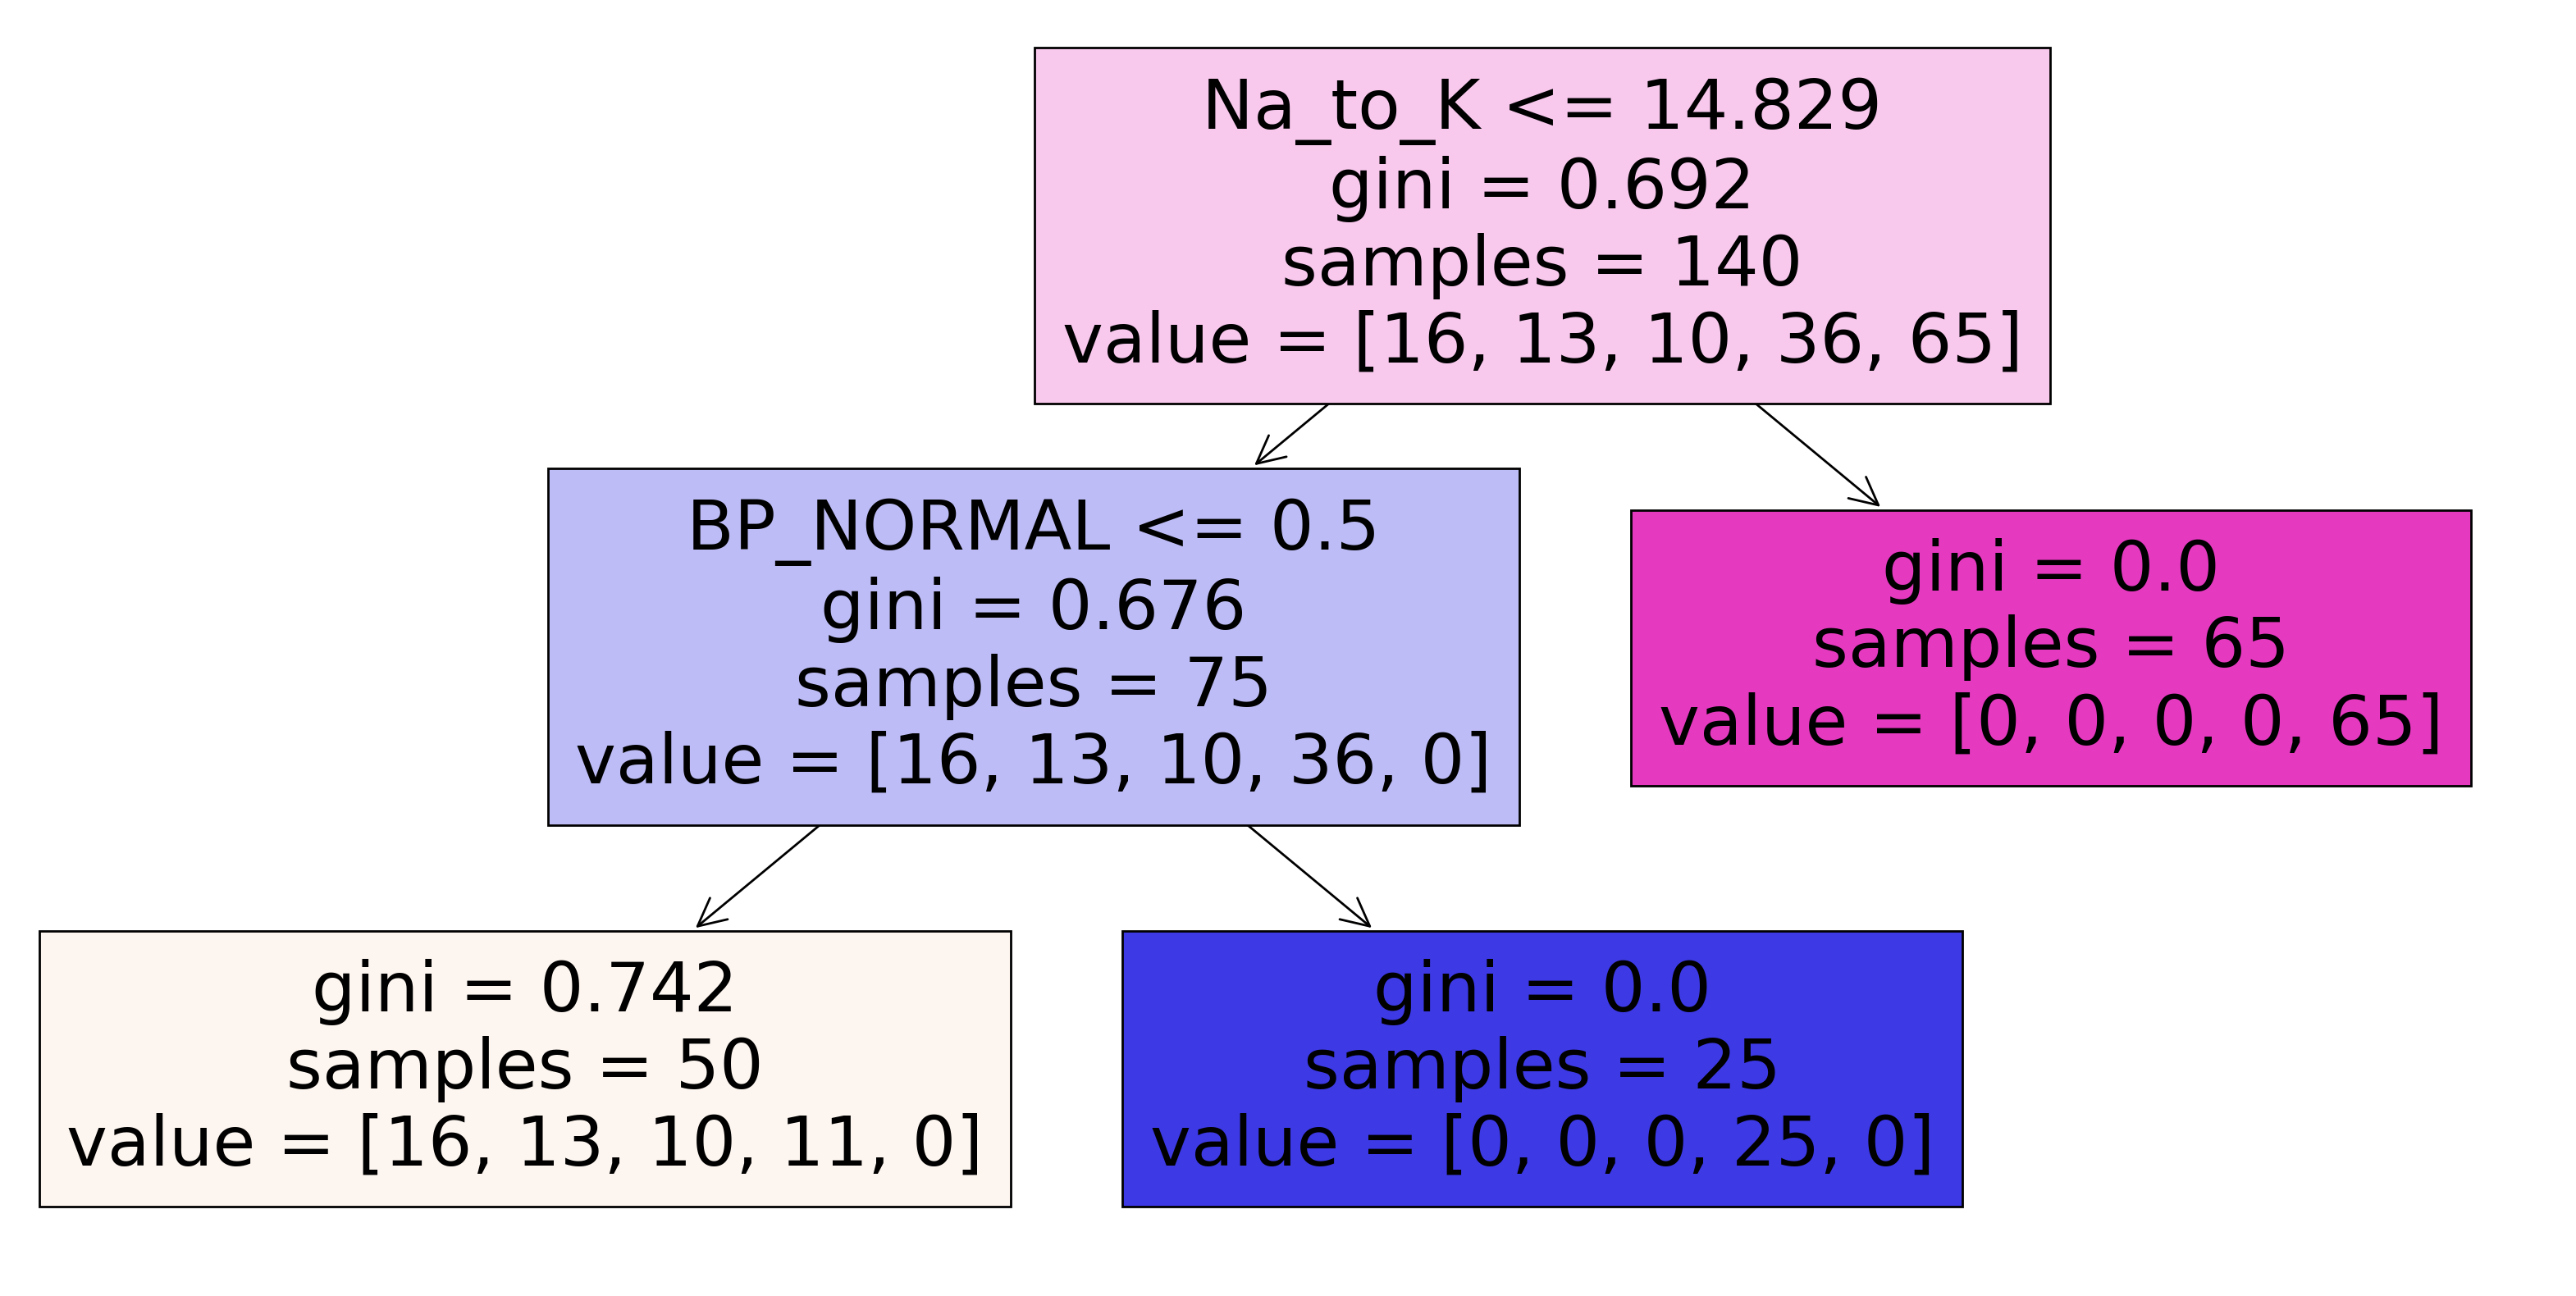

In [35]:
report_model(pruned_tree)

## Decision tree with a maximum number of leaf nodes model development

In [36]:
max_leaf_tree = DecisionTreeClassifier(max_leaf_nodes = 5)

In [47]:
max_leaf_tree.fit(X_train,y_train)

DecisionTreeClassifier(max_leaf_nodes=5)

## Display the maximum leaf nodes Decision Tree rules

In [48]:
rules_max_leaf = export_text(max_leaf_tree, feature_names=X.columns.tolist())
print(rules_max_leaf)

|--- Na_to_K <= 14.83
|   |--- BP_NORMAL <= 0.50
|   |   |--- BP_LOW <= 0.50
|   |   |   |--- Age <= 50.50
|   |   |   |   |--- class: drugA
|   |   |   |--- Age >  50.50
|   |   |   |   |--- class: drugB
|   |   |--- BP_LOW >  0.50
|   |   |   |--- class: drugX
|   |--- BP_NORMAL >  0.50
|   |   |--- class: drugX
|--- Na_to_K >  14.83
|   |--- class: drugY



## Decision Tree with a maximum number of leaf nodes: Model evaluation

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         3
       drugC       0.00      0.00      0.00         6
       drugX       0.75      1.00      0.86        18
       drugY       1.00      1.00      1.00        26

    accuracy                           0.90        60
   macro avg       0.75      0.80      0.77        60
weighted avg       0.82      0.90      0.86        60





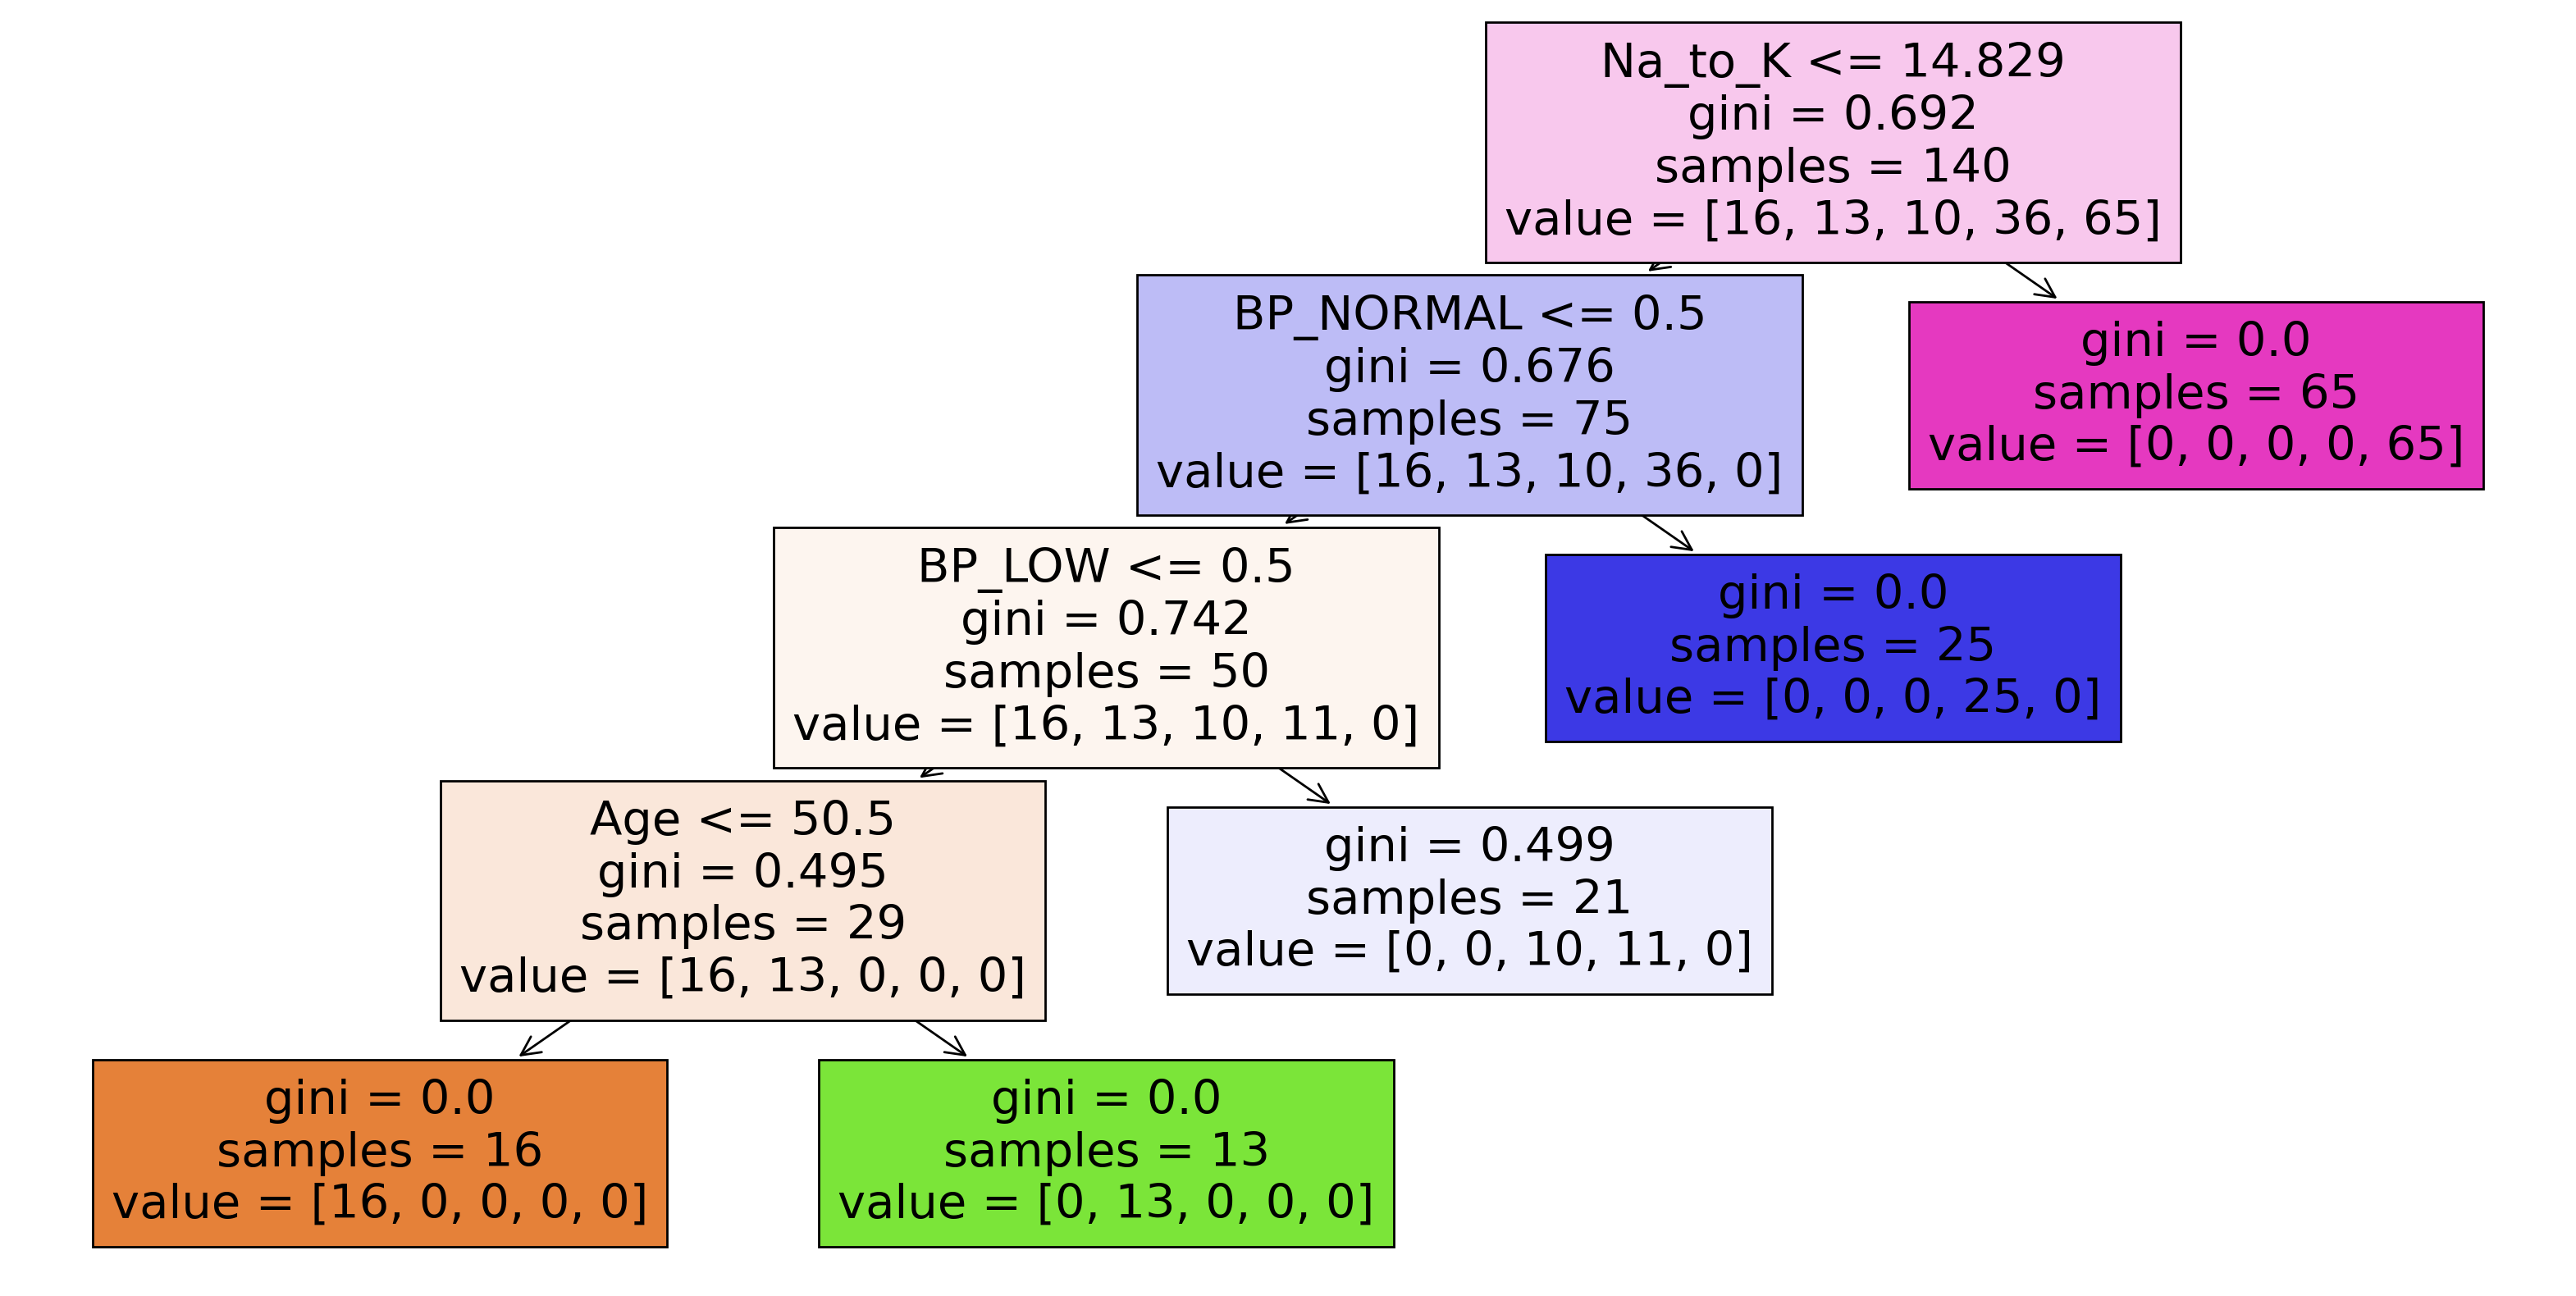

In [49]:
report_model(max_leaf_tree)

 ## Decision Tree (Entropy-based criterion): Model development

In [39]:
entropy_tree = DecisionTreeClassifier(criterion = 'entropy')

In [40]:
entropy_tree.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

## Display the Entropy-based Decision Tree rules

In [46]:
rules_entropy = export_text(entropy_tree, feature_names=X.columns.tolist())
print(rules_entropy)

|--- Na_to_K <= 14.83
|   |--- BP_NORMAL <= 0.50
|   |   |--- BP_LOW <= 0.50
|   |   |   |--- Age <= 50.50
|   |   |   |   |--- class: drugA
|   |   |   |--- Age >  50.50
|   |   |   |   |--- class: drugB
|   |   |--- BP_LOW >  0.50
|   |   |   |--- Cholesterol_NORMAL <= 0.50
|   |   |   |   |--- class: drugC
|   |   |   |--- Cholesterol_NORMAL >  0.50
|   |   |   |   |--- class: drugX
|   |--- BP_NORMAL >  0.50
|   |   |--- class: drugX
|--- Na_to_K >  14.83
|   |--- class: drugY



## Decision Tree (Entropy-based criterion): Model evaluation

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         6
       drugX       1.00      1.00      1.00        18
       drugY       1.00      1.00      1.00        26

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60





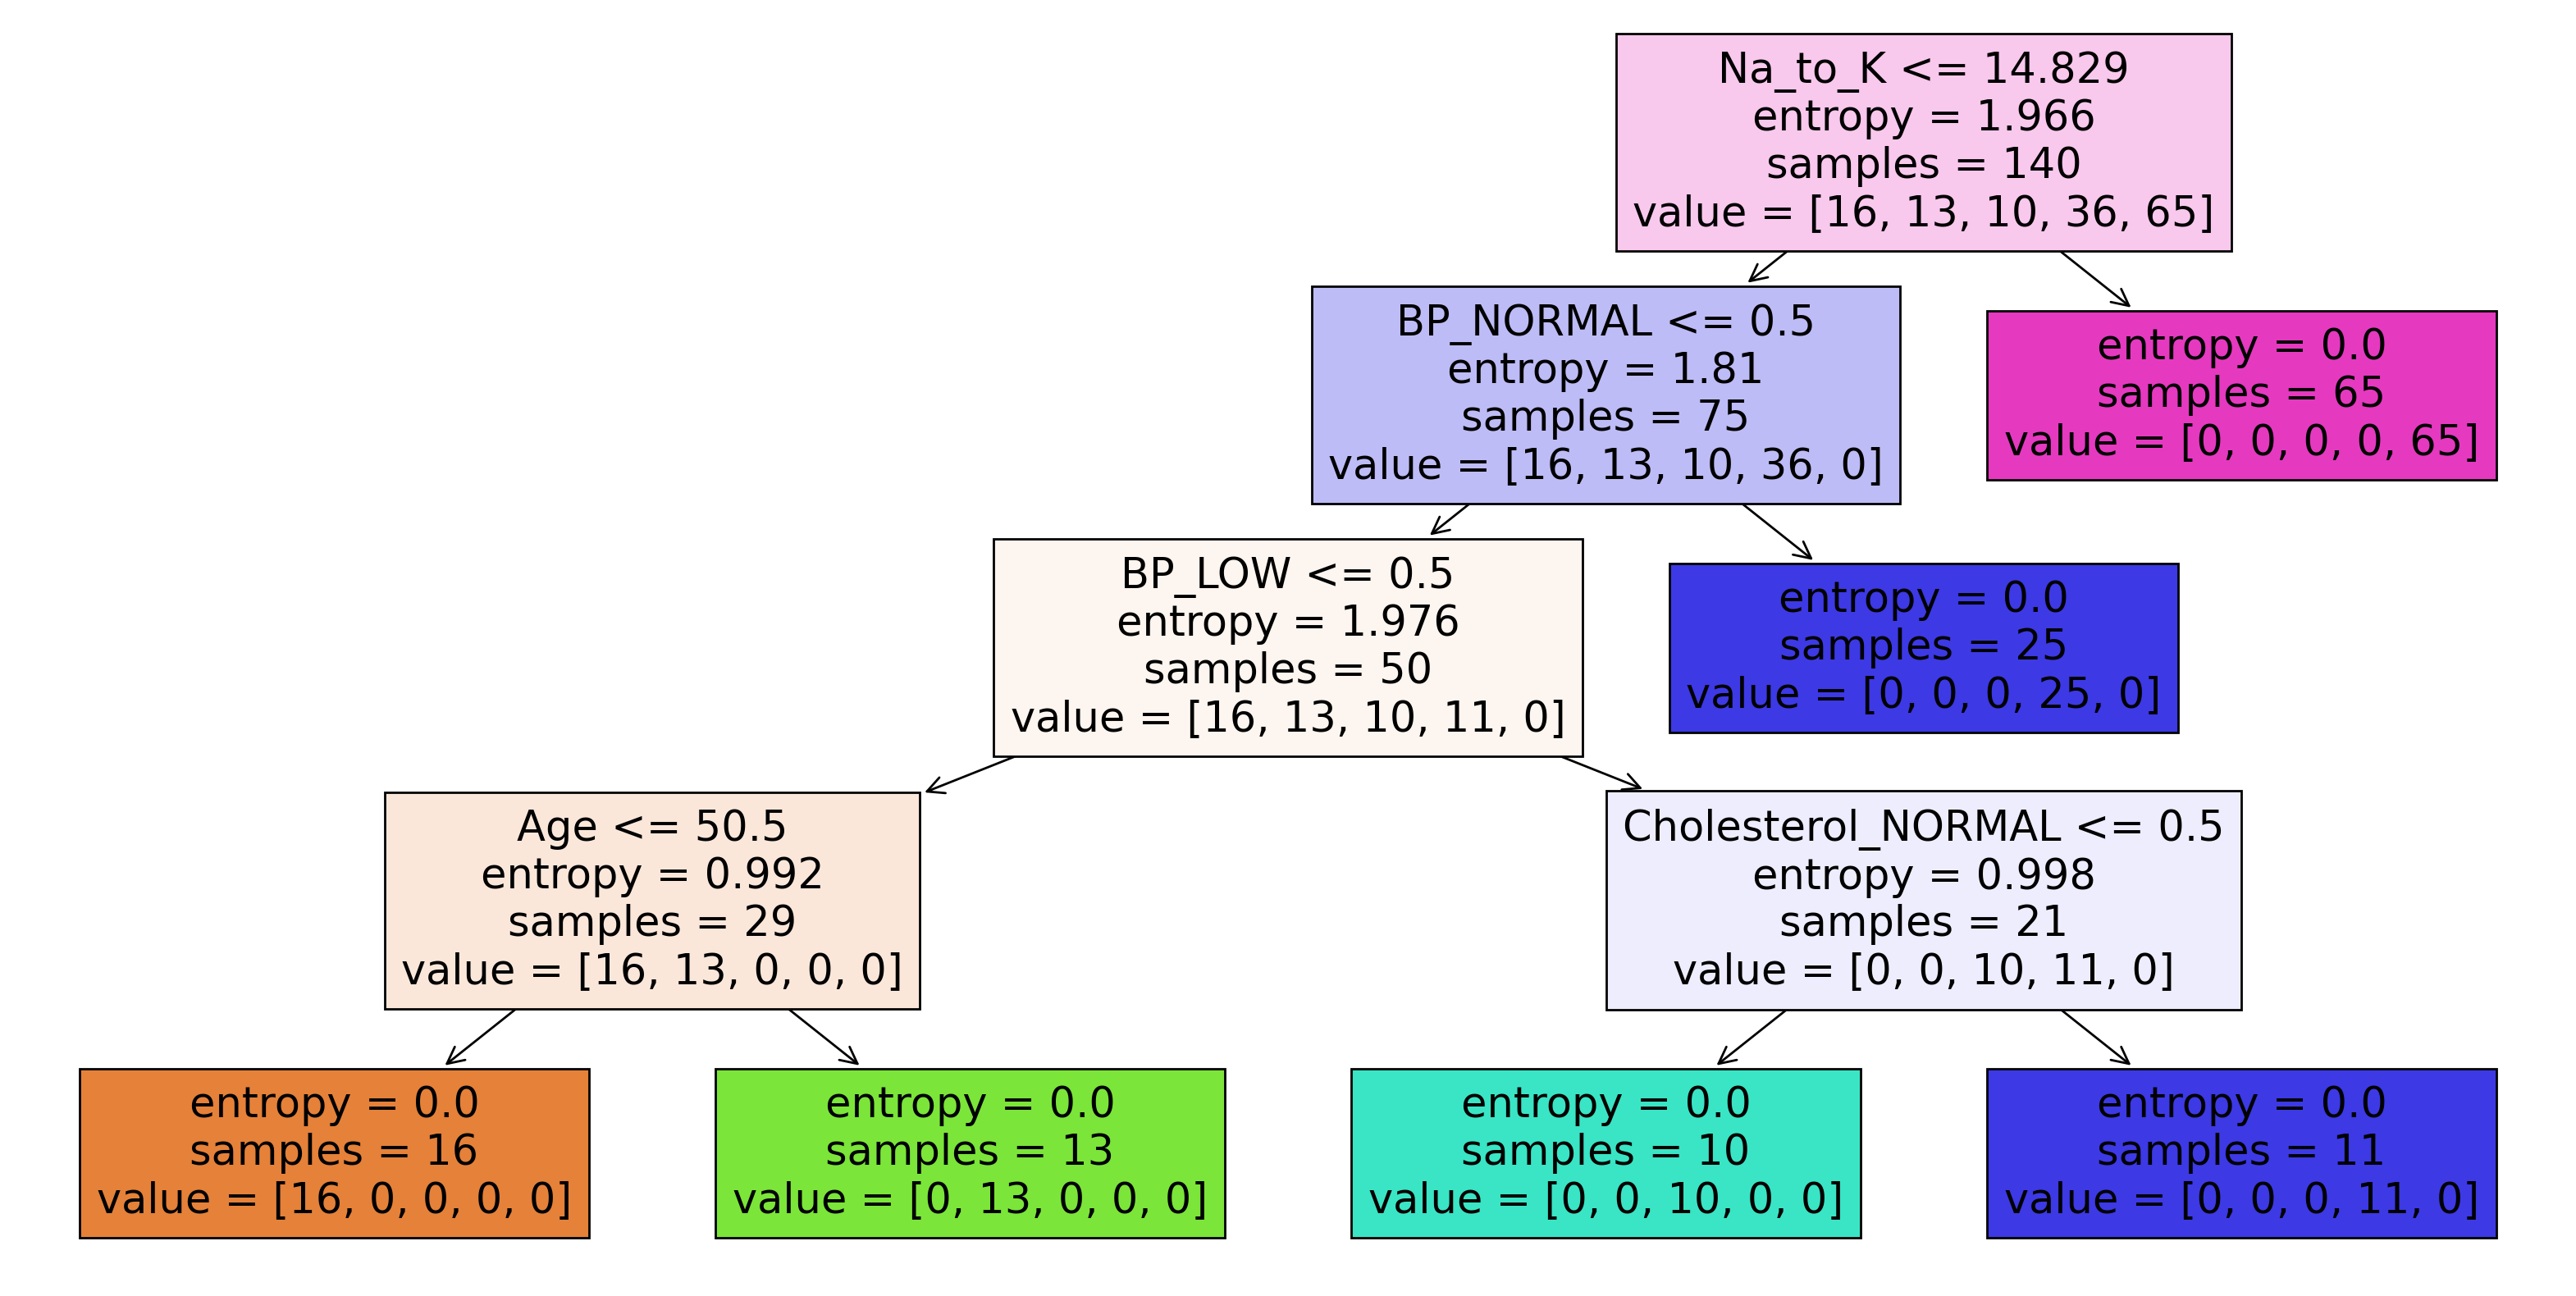

In [41]:
report_model(entropy_tree)

## Conclusions

### Model comparison
The baseline Decision Tree classifier achieved the best overall performance among the evaluated models. Although pruning strategies (maximum depth and maximum number of leaf nodes) reduced model complexity, they did not improve predictive accuracy on the test set. The Decision Tree using the Gini criterion provided the best balance between classification performance and interpretability.

### Prediction for a new pacient
The trained models were used to predict the most appropriate drug for a new patient. Most models recommended DrugY, primarily because the patient's Na_to_K ratio exceeded the main decision threshold learned by the classifier. The only exception was the model constrained by the maximum number of leaf nodes, which produced a different prediction due to its simplified decision structure.
Overall, this project demonstrates how Decision Tree hyperparameters influence model complexity, interpretability, and predictive performance. It also highlights the importance of feature importance analysis and model comparison when selecting the most appropriate classifier.

## Final remarks
This project demonstrates the complete workflow of a supervised classification problem, from exploratory data analysis and feature engineering to model training, evaluation, and interpretation. Comparing multiple Decision Tree configurations highlights how hyperparameter tuning affects model complexity, interpretability, and predictive performance.